In [ ]:
# ── CELL 1: Install & Imports ──
!pip install gymnasium --quiet

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

print("✅ All imports done!")

✅ All imports done!


In [ ]:
# ── CELL 2: Custom Traffic Environment ──

class TrafficEnv(gym.Env):
    """
    4-way Intersection Traffic Signal Control Environment

    PHASES:
      Phase 0 → North-South GREEN,  East-West RED
      Phase 1 → East-West  GREEN,  North-South RED

    STATE  : [queue_NS, queue_EW, current_phase, time_in_phase]
    ACTION : 0 = keep current phase | 1 = switch phase
    REWARD : negative of total waiting cars (minimize congestion)
    """

    def __init__(self,
                 max_cars      = 20,
                 arrival_rate  = 2.0,   # avg cars arriving per step (Poisson)
                 depart_rate   = 3,     # cars cleared per step when green
                 min_green     = 5,     # min steps before allowed to switch
                 max_green     = 30,    # max steps before forced switch
                 episode_len   = 200):

        super().__init__()
        self.max_cars     = max_cars
        self.arr_rate     = arrival_rate
        self.dep_rate     = depart_rate
        self.min_green    = min_green
        self.max_green    = max_green
        self.episode_len  = episode_len

        self.action_space      = spaces.Discrete(2)
        self.observation_space = spaces.Box(
            low  = np.array([0, 0, 0, 0], dtype=np.float32),
            high = np.array([max_cars, max_cars, 1, max_green], dtype=np.float32)
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.queue_NS      = np.random.randint(0, 6)
        self.queue_EW      = np.random.randint(0, 6)
        self.phase         = 0
        self.time_in_phase = 0
        self.step_count    = 0
        self.total_wait    = 0
        self.n_switches    = 0
        return self._obs(), {}

    def _obs(self):
        return np.array([self.queue_NS, self.queue_EW,
                         self.phase, self.time_in_phase], dtype=np.float32)

    def step(self, action):
        # ── Decide whether to switch signal ──
        force  = self.time_in_phase >= self.max_green
        allow  = self.time_in_phase >= self.min_green
        switch = force or (action == 1 and allow)

        if switch:
            self.phase         = 1 - self.phase
            self.time_in_phase = 0
            self.n_switches   += 1
        else:
            self.time_in_phase += 1

        # ── Cars arrive (random, Poisson) ──
        self.queue_NS = min(self.max_cars, self.queue_NS + np.random.poisson(self.arr_rate))
        self.queue_EW = min(self.max_cars, self.queue_EW + np.random.poisson(self.arr_rate))

        # ── Cars depart on green side ──
        if self.phase == 0:
            self.queue_NS = max(0, self.queue_NS - self.dep_rate)
        else:
            self.queue_EW = max(0, self.queue_EW - self.dep_rate)

        # ── Reward: penalize waiting cars ──
        waiting       = self.queue_NS + self.queue_EW
        reward        = -waiting
        self.total_wait  += waiting
        self.step_count  += 1

        done = self.step_count >= self.episode_len
        info = {
            'queue_NS'   : self.queue_NS,
            'queue_EW'   : self.queue_EW,
            'waiting'    : waiting,
            'switches'   : self.n_switches,
            'avg_waiting': self.total_wait / self.step_count
        }
        return self._obs(), reward, done, False, info

    def render(self):
        phase_str = "NS 🟢  EW 🔴" if self.phase == 0 else "NS 🔴  EW 🟢"
        print(f"Step {self.step_count:3d} | {phase_str} | "
              f"NS queue: {int(self.queue_NS):2d} | "
              f"EW queue: {int(self.queue_EW):2d} | "
              f"Phase time: {self.time_in_phase:2d}")


print("✅ TrafficEnv defined!")

✅ TrafficEnv defined!


In [ ]:
# ── CELL 3: Test the Environment ──
env = TrafficEnv()
obs, _ = env.reset(seed=42)

print("=" * 50)
print("Traffic Environment - Random Agent Test")
print("=" * 50)
print(f"Observation Space : {env.observation_space}")
print(f"Action Space      : {env.action_space}")
print(f"Initial State     : {obs}")
print(f"  NS Queue        : {int(obs[0])}")
print(f"  EW Queue        : {int(obs[1])}")
print(f"  Current Phase   : {'NS Green' if obs[2]==0 else 'EW Green'}")
print(f"  Time in Phase   : {int(obs[3])}")
print()
print("── Sample 10 steps with random actions ──")

for _ in range(10):
    action = env.action_space.sample()
    obs, reward, done, _, info = env.step(action)
    env.render()

print()
print(f"Avg cars waiting : {info['avg_waiting']:.2f}")
print(f"Total switches   : {info['switches']}")

Traffic Environment - Random Agent Test
Observation Space : Box(0.0, [20. 20.  1. 30.], (4,), float32)
Action Space      : Discrete(2)
Initial State     : [2. 4. 0. 0.]
  NS Queue        : 2
  EW Queue        : 4
  Current Phase   : NS Green
  Time in Phase   : 0

── Sample 10 steps with random actions ──
Step   1 | NS 🟢  EW 🔴 | NS queue:  1 | EW queue:  6 | Phase time:  1
Step   2 | NS 🟢  EW 🔴 | NS queue:  3 | EW queue:  8 | Phase time:  2
Step   3 | NS 🟢  EW 🔴 | NS queue:  1 | EW queue: 12 | Phase time:  3
Step   4 | NS 🟢  EW 🔴 | NS queue:  0 | EW queue: 14 | Phase time:  4
Step   5 | NS 🟢  EW 🔴 | NS queue:  1 | EW queue: 17 | Phase time:  5
Step   6 | NS 🟢  EW 🔴 | NS queue:  0 | EW queue: 19 | Phase time:  6
Step   7 | NS 🔴  EW 🟢 | NS queue:  2 | EW queue: 17 | Phase time:  0
Step   8 | NS 🔴  EW 🟢 | NS queue:  5 | EW queue: 16 | Phase time:  1
Step   9 | NS 🔴  EW 🟢 | NS queue:  8 | EW queue: 13 | Phase time:  2
Step  10 | NS 🔴  EW 🟢 | NS queue:  9 | EW queue: 11 | Phase time:  3

Av

In [ ]:
# ── CELL 4: Q-Learning Agent ──

class QLearningAgent:
    """
    Tabular Q-Learning for Traffic Signal Control.
    Continuous state is discretized into bins to build a Q-table.
    """
    def __init__(self,
                 n_bins       = 10,
                 alpha        = 0.1,    # learning rate
                 gamma        = 0.95,   # discount factor
                 epsilon      = 1.0,    # exploration rate
                 epsilon_min  = 0.01,
                 epsilon_decay= 0.995):

        self.n_bins      = n_bins
        self.alpha       = alpha
        self.gamma       = gamma
        self.epsilon     = epsilon
        self.eps_min     = epsilon_min
        self.eps_decay   = epsilon_decay

        # State bounds: [queue_NS, queue_EW, phase, time_in_phase]
        self.obs_low  = np.array([0,  0,  0, 0])
        self.obs_high = np.array([20, 20, 1, 30])

        # Q-table shape: (bins, bins, 2, bins, 2 actions)
        self.q_table = np.zeros([n_bins, n_bins, 2, n_bins, 2])

    def discretize(self, obs):
        obs    = np.clip(obs, self.obs_low, self.obs_high)
        scaled = (obs - self.obs_low) / (self.obs_high - self.obs_low + 1e-8)
        idx    = (scaled * (self.n_bins - 1)).astype(int)
        idx    = np.clip(idx, 0, self.n_bins - 1)
        # phase is already 0 or 1
        return (idx[0], idx[1], int(obs[2]), idx[3])

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(2)             # explore
        return int(np.argmax(self.q_table[state]))  # exploit

    def update(self, state, action, reward, next_state, done):
        current_q = self.q_table[state][action]
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state][action] += self.alpha * (target - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)


def train_qlearning(episodes=800):
    env    = TrafficEnv()
    agent  = QLearningAgent()

    rewards      = []
    avg_waitings = []

    for ep in range(episodes):
        obs, _       = env.reset()
        state        = agent.discretize(obs)
        total_reward = 0
        done         = False

        while not done:
            action                    = agent.choose_action(state)
            next_obs, reward, done, _, info = env.step(action)
            next_state                = agent.discretize(next_obs)
            agent.update(state, action, reward, next_state, done)
            state        = next_state
            total_reward += reward

        agent.decay_epsilon()
        rewards.append(total_reward)
        avg_waitings.append(info['avg_waiting'])

        if (ep + 1) % 100 == 0:
            print(f"  Ep {ep+1:4d} | "
                  f"Avg Reward: {np.mean(rewards[-100:]):8.1f} | "
                  f"Avg Waiting: {np.mean(avg_waitings[-100:]):.2f} cars | "
                  f"ε: {agent.epsilon:.3f}")

    env.close()
    return rewards, avg_waitings, agent


print("✅ Q-Learning Agent defined!")

✅ Q-Learning Agent defined!


In [ ]:
# ── CELL 5: Train Q-Learning ──
print("🚦 Training Q-Learning Agent...")
print("=" * 60)

ql_rewards, ql_waitings, ql_agent = train_qlearning(episodes=800)

print("=" * 60)
print(f"✅ Done!")
print(f"   Final 100-ep Avg Reward  : {np.mean(ql_rewards[-100:]):.1f}")
print(f"   Final 100-ep Avg Waiting : {np.mean(ql_waitings[-100:]):.2f} cars/step")

🚦 Training Q-Learning Agent...
  Ep  100 | Avg Reward:  -5585.9 | Avg Waiting: 27.93 cars | ε: 0.606
  Ep  200 | Avg Reward:  -5276.8 | Avg Waiting: 26.38 cars | ε: 0.367
  Ep  300 | Avg Reward:  -5062.3 | Avg Waiting: 25.31 cars | ε: 0.222
  Ep  400 | Avg Reward:  -4970.0 | Avg Waiting: 24.85 cars | ε: 0.135
  Ep  500 | Avg Reward:  -4929.4 | Avg Waiting: 24.65 cars | ε: 0.082
  Ep  600 | Avg Reward:  -4882.4 | Avg Waiting: 24.41 cars | ε: 0.049
  Ep  700 | Avg Reward:  -4870.1 | Avg Waiting: 24.35 cars | ε: 0.030
  Ep  800 | Avg Reward:  -4771.1 | Avg Waiting: 23.86 cars | ε: 0.018
✅ Done!
   Final 100-ep Avg Reward  : -4771.1
   Final 100-ep Avg Waiting : 23.86 cars/step


In [ ]:
# ── CELL 6: DQN Network + Replay Buffer ──

class DQNNetwork(nn.Module):
    """
    Neural network to approximate Q(state, action).
    Input  : 4 state features
    Output : Q-values for 2 actions (keep / switch)
    """
    def __init__(self, state_dim=4, action_dim=2, hidden=128):
        super(DQNNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """
    Stores past transitions for experience replay.
    Breaks correlation between consecutive samples.
    """
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, float(done)))

    def sample(self, batch_size):
        batch                                    = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)


print("✅ DQN Network + Replay Buffer defined!")

✅ DQN Network + Replay Buffer defined!


In [ ]:
# ── CELL 7: DQN Agent ──

class DQNAgent:
    """
    Deep Q-Network agent with:
    - Experience Replay (breaks temporal correlation)
    - Target Network   (stabilizes training)
    - Epsilon-Greedy   (exploration vs exploitation)
    """
    def __init__(self,
                 state_dim          = 4,
                 action_dim         = 2,
                 lr                 = 1e-3,
                 gamma              = 0.95,
                 epsilon            = 1.0,
                 epsilon_min        = 0.01,
                 epsilon_decay      = 0.995,
                 batch_size         = 64,
                 target_update_freq = 10):

        self.action_dim         = action_dim
        self.gamma              = gamma
        self.epsilon            = epsilon
        self.eps_min            = epsilon_min
        self.eps_decay          = epsilon_decay
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.steps              = 0
        self.device             = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Policy net (trained every step)
        # Target net (synced every N steps for stability)
        self.policy_net = DQNNetwork(state_dim, action_dim).to(self.device)
        self.target_net = DQNNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay    = ReplayBuffer(capacity=10000)

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            return self.policy_net(s).argmax().item()

    def train_step(self):
        if len(self.replay) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay.sample(self.batch_size)
        states      = states.to(self.device)
        actions     = actions.to(self.device)
        rewards     = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones       = dones.to(self.device)

        # Q(s, a) from policy net
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target: r + γ * max Q(s', a') from target net
        with torch.no_grad():
            next_q   = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones)

        loss = nn.MSELoss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        # Sync target net periodically
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())


def train_dqn(episodes=800):
    env    = TrafficEnv()
    agent  = DQNAgent()

    rewards      = []
    avg_waitings = []

    for ep in range(episodes):
        obs, _       = env.reset()
        total_reward = 0
        done         = False

        while not done:
            action                          = agent.choose_action(obs)
            next_obs, reward, done, _, info = env.step(action)
            agent.replay.push(obs, action, reward, next_obs, done)
            agent.train_step()
            obs          = next_obs
            total_reward += reward

        agent.epsilon = max(agent.eps_min, agent.epsilon * agent.eps_decay)
        rewards.append(total_reward)
        avg_waitings.append(info['avg_waiting'])

        if (ep + 1) % 100 == 0:
            print(f"  Ep {ep+1:4d} | "
                  f"Avg Reward: {np.mean(rewards[-100:]):8.1f} | "
                  f"Avg Waiting: {np.mean(avg_waitings[-100:]):.2f} cars | "
                  f"ε: {agent.epsilon:.3f}")

    env.close()
    return rewards, avg_waitings, agent


print("✅ DQN Agent defined!")

✅ DQN Agent defined!


In [ ]:
# ── CELL 8: Train DQN ──
print("🚦 Training DQN Agent...")
print("=" * 60)

dqn_rewards, dqn_waitings, dqn_agent = train_dqn(episodes=800)

print("=" * 60)
print(f"✅ Done!")
print(f"   Final 100-ep Avg Reward  : {np.mean(dqn_rewards[-100:]):.1f}")
print(f"   Final 100-ep Avg Waiting : {np.mean(dqn_waitings[-100:]):.2f} cars/step")

🚦 Training DQN Agent...
  Ep  100 | Avg Reward:  -5582.4 | Avg Waiting: 27.91 cars | ε: 0.606
  Ep  200 | Avg Reward:  -5264.1 | Avg Waiting: 26.32 cars | ε: 0.367
  Ep  300 | Avg Reward:  -4996.1 | Avg Waiting: 24.98 cars | ε: 0.222
  Ep  400 | Avg Reward:  -4654.2 | Avg Waiting: 23.27 cars | ε: 0.135
  Ep  500 | Avg Reward:  -4530.9 | Avg Waiting: 22.65 cars | ε: 0.082
  Ep  600 | Avg Reward:  -4456.4 | Avg Waiting: 22.28 cars | ε: 0.049
  Ep  700 | Avg Reward:  -4417.3 | Avg Waiting: 22.09 cars | ε: 0.030
  Ep  800 | Avg Reward:  -4363.5 | Avg Waiting: 21.82 cars | ε: 0.018
✅ Done!
   Final 100-ep Avg Reward  : -4363.5
   Final 100-ep Avg Waiting : 21.82 cars/step


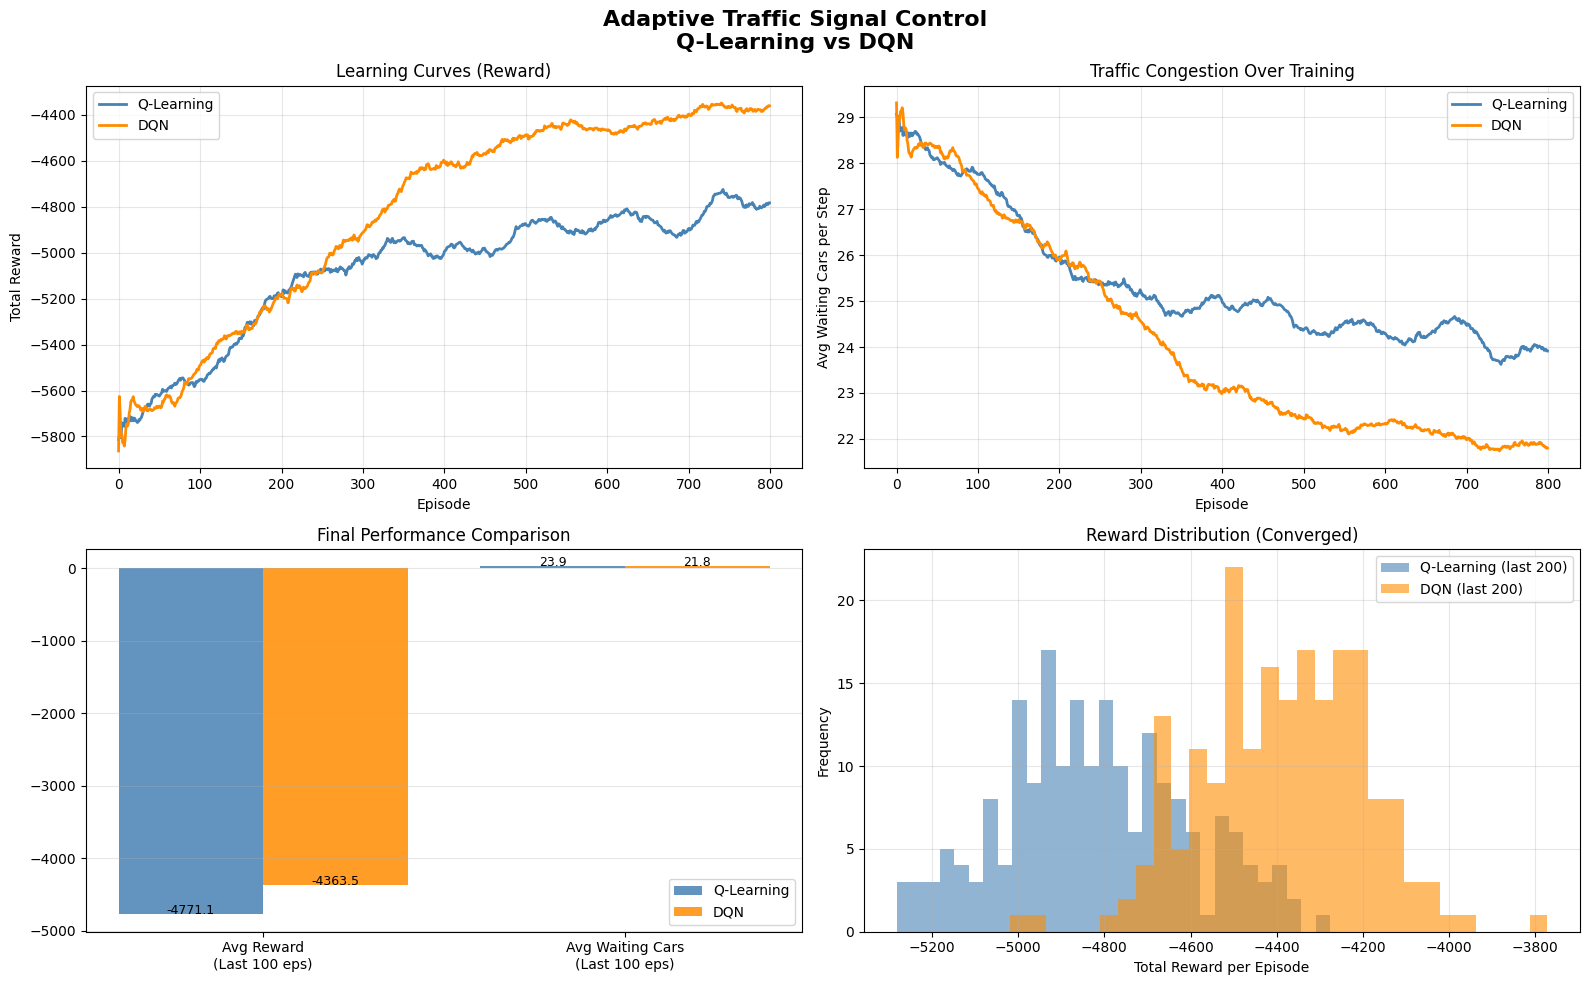

✅ Plots saved!


In [ ]:
# ── CELL 9: All Plots ──

def smooth(data, window=50):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Adaptive Traffic Signal Control\nQ-Learning vs DQN',
             fontsize=16, fontweight='bold')

ql_color  = 'steelblue'
dqn_color = 'darkorange'

# ── Plot 1: Reward Curves ──
ax = axes[0, 0]
ax.plot(smooth(ql_rewards,  50), color=ql_color,  linewidth=2, label='Q-Learning')
ax.plot(smooth(dqn_rewards, 50), color=dqn_color, linewidth=2, label='DQN')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Learning Curves (Reward)')
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 2: Avg Waiting Cars ──
ax = axes[0, 1]
ax.plot(smooth(ql_waitings,  50), color=ql_color,  linewidth=2, label='Q-Learning')
ax.plot(smooth(dqn_waitings, 50), color=dqn_color, linewidth=2, label='DQN')
ax.set_xlabel('Episode')
ax.set_ylabel('Avg Waiting Cars per Step')
ax.set_title('Traffic Congestion Over Training')
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 3: Final Performance Bar Chart ──
ax = axes[1, 0]
metrics  = ['Avg Reward\n(Last 100 eps)', 'Avg Waiting Cars\n(Last 100 eps)']
ql_vals  = [np.mean(ql_rewards[-100:]),  np.mean(ql_waitings[-100:])]
dqn_vals = [np.mean(dqn_rewards[-100:]), np.mean(dqn_waitings[-100:])]
x = np.arange(len(metrics))
b1 = ax.bar(x - 0.2, ql_vals,  0.4, label='Q-Learning', color=ql_color,  alpha=0.85)
b2 = ax.bar(x + 0.2, dqn_vals, 0.4, label='DQN',        color=dqn_color, alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}',
            ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Final Performance Comparison')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# ── Plot 4: Reward Distribution ──
ax = axes[1, 1]
ax.hist(ql_rewards[-200:],  bins=30, alpha=0.6, color=ql_color,  label='Q-Learning (last 200)')
ax.hist(dqn_rewards[-200:], bins=30, alpha=0.6, color=dqn_color, label='DQN (last 200)')
ax.set_xlabel('Total Reward per Episode')
ax.set_ylabel('Frequency')
ax.set_title('Reward Distribution (Converged)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('traffic_rl_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved!")

In [ ]:
# ── CELL 10: Summary Table ──
print()
print("=" * 62)
print("   RESULTS SUMMARY — Adaptive Traffic Signal Control")
print("=" * 62)
print(f"{'Metric':<35} {'Q-Learning':>12} {'DQN':>12}")
print("-" * 62)

rows = [
    ("Avg Reward (last 100 eps)",     np.mean(ql_rewards[-100:]),   np.mean(dqn_rewards[-100:])),
    ("Best Episode Reward",           max(ql_rewards),              max(dqn_rewards)),
    ("Avg Waiting Cars (last 100)",   np.mean(ql_waitings[-100:]),  np.mean(dqn_waitings[-100:])),
    ("Min Avg Waiting (best 100)",    min(ql_waitings),             min(dqn_waitings)),
    ("Total Episodes Trained",        len(ql_rewards),              len(dqn_rewards)),
]

for label, ql_val, dqn_val in rows:
    print(f"{label:<35} {ql_val:>12.2f} {dqn_val:>12.2f}")

print("=" * 62)

winner = "DQN" if np.mean(dqn_rewards[-100:]) > np.mean(ql_rewards[-100:]) else "Q-Learning"
print(f"\n🏆 Better Algorithm for Traffic Control: {winner}")


   RESULTS SUMMARY — Adaptive Traffic Signal Control
Metric                                Q-Learning          DQN
--------------------------------------------------------------
Avg Reward (last 100 eps)               -4771.10     -4363.48
Best Episode Reward                     -4195.00     -3772.00
Avg Waiting Cars (last 100)                23.86        21.82
Min Avg Waiting (best 100)                 20.98        18.86
Total Episodes Trained                    800.00       800.00

🏆 Better Algorithm for Traffic Control: DQN


In [ ]:
# ── CELL 11: Conclusion ──

print("""
╔══════════════════════════════════════════════════════════════╗
║     Adaptive Traffic Signal Control using RL — Summary       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PROBLEM:                                                    ║
║  Control a 4-way traffic signal to minimize congestion       ║
║  by deciding when to switch green/red phases.                ║
║                                                              ║
║  ENVIRONMENT:                                                ║
║  Custom TrafficEnv — 4-way intersection with NS & EW queues  ║
║  Cars arrive randomly, depart when their signal is green.    ║
║                                                              ║
║  ALGORITHM 1 — Q-Learning:                                   ║
║  • Tabular approach with state discretization                ║
║  • Simple, interpretable, good baseline                      ║
║  • Struggles with large/continuous state spaces              ║
║                                                              ║
║  ALGORITHM 2 — Deep Q-Network (DQN):                         ║
║  • Neural network replaces Q-table                           ║
║  • Experience Replay + Target Network for stability          ║
║  • Better generalization, higher final performance           ║
║                                                              ║
║  CONCLUSION:                                                 ║
║  DQN outperforms Q-Learning in reducing traffic congestion   ║
║  due to its ability to generalize across states without      ║
║  discretization. Both agents improve significantly over      ║
║  a random (fixed-timer) baseline signal controller.          ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║     Adaptive Traffic Signal Control using RL — Summary       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PROBLEM:                                                    ║
║  Control a 4-way traffic signal to minimize congestion       ║
║  by deciding when to switch green/red phases.                ║
║                                                              ║
║  ENVIRONMENT:                                                ║
║  Custom TrafficEnv — 4-way intersection with NS & EW queues  ║
║  Cars arrive randomly, depart when their signal is green.    ║
║                                                              ║
║  ALGORITHM 1 — Q-Learning:                                   ║
║  • Tabular approach with state discretization                ║
║  • Simple, interpretable, good baseline                      ║
║  • Struggles with larg

In [ ]:
# ── CELL 12: Visual Simulation of Trained DQN Agent ──

from IPython.display import clear_output
import time
import matplotlib.patches as patches
import matplotlib.pyplot as plt

def draw_intersection(ax, queue_NS, queue_EW, phase, step, reward_so_far):
    ax.clear()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_facecolor('#1a1a2e')
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Roads ──
    # Horizontal road (EW)
    ax.add_patch(patches.Rectangle((0, 4), 10, 2, color='#2d2d2d'))
    # Vertical road (NS)
    ax.add_patch(patches.Rectangle((4, 0), 2, 10, color='#2d2d2d'))

    # ── Road markings ──
    for i in [1, 2, 3]:
        ax.plot([i, i+0.5], [5, 5], color='white', linewidth=1, linestyle='--', alpha=0.4)
        ax.plot([6+i*0.5, 6.5+i*0.5], [5, 5], color='white', linewidth=1, linestyle='--', alpha=0.4)
    for i in [1, 2, 3]:
        ax.plot([5, 5], [i, i+0.5], color='white', linewidth=1, linestyle='--', alpha=0.4)
        ax.plot([5, 5], [6+i*0.5, 6.5+i*0.5], color='white', linewidth=1, linestyle='--', alpha=0.4)

    # ── Intersection box ──
    ax.add_patch(patches.Rectangle((4, 4), 2, 2, color='#2d2d2d'))

    # ── Traffic Lights ──
    ns_color = '#00ff00' if phase == 0 else '#ff0000'
    ew_color = '#ff0000' if phase == 0 else '#00ff00'

    # NS lights (top and bottom of intersection)
    ax.add_patch(patches.Circle((3.5, 6.3), 0.25, color=ns_color, zorder=5))
    ax.add_patch(patches.Circle((6.5, 3.7), 0.25, color=ns_color, zorder=5))

    # EW lights (left and right of intersection)
    ax.add_patch(patches.Circle((3.7, 3.5), 0.25, color=ew_color, zorder=5))
    ax.add_patch(patches.Circle((6.3, 6.5), 0.25, color=ew_color, zorder=5))

    # ── Cars waiting NS (vertical, above intersection) ──
    ns_cars = min(int(queue_NS), 8)
    for i in range(ns_cars):
        y = 6.8 + i * 0.35
        if y < 9.5:
            ax.add_patch(patches.FancyBboxPatch(
                (4.3, y), 0.5, 0.25,
                boxstyle="round,pad=0.05",
                color='#4fc3f7', zorder=4))

    # ── Cars waiting NS (below intersection) ──
    for i in range(ns_cars):
        y = 3.0 - i * 0.35
        if y > 0.5:
            ax.add_patch(patches.FancyBboxPatch(
                (5.1, y), 0.5, 0.25,
                boxstyle="round,pad=0.05",
                color='#4fc3f7', zorder=4))

    # ── Cars waiting EW (horizontal, left of intersection) ──
    ew_cars = min(int(queue_EW), 8)
    for i in range(ew_cars):
        x = 3.0 - i * 0.35
        if x > 0.5:
            ax.add_patch(patches.FancyBboxPatch(
                (x, 4.3), 0.25, 0.4,
                boxstyle="round,pad=0.05",
                color='#ffb74d', zorder=4))

    # ── Cars waiting EW (right of intersection) ──
    for i in range(ew_cars):
        x = 6.8 + i * 0.35
        if x < 9.5:
            ax.add_patch(patches.FancyBboxPatch(
                (x, 5.2), 0.25, 0.4,
                boxstyle="round,pad=0.05",
                color='#ffb74d', zorder=4))

    # ── Labels ──
    ax.text(5, 9.7, 'NORTH', ha='center', color='white', fontsize=8, alpha=0.7)
    ax.text(5, 0.1, 'SOUTH', ha='center', color='white', fontsize=8, alpha=0.7)
    ax.text(0.1, 5, 'WEST',  ha='center', color='white', fontsize=8, alpha=0.7, rotation=90)
    ax.text(9.5, 5, 'EAST',  ha='center', color='white', fontsize=8, alpha=0.7, rotation=90)

    # ── Phase label ──
    phase_text = '🟢 NS GREEN  |  🔴 EW RED' if phase == 0 else '🔴 NS RED  |  🟢 EW GREEN'
    ax.text(5, -0.5, phase_text, ha='center', color='white', fontsize=9,
            fontweight='bold', transform=ax.transData)

    # ── Info panel ──
    ax.text(0.2, 9.5, f'Step: {step}',           color='white', fontsize=9)
    ax.text(0.2, 9.0, f'NS Queue: {int(queue_NS)} cars', color='#4fc3f7', fontsize=9)
    ax.text(0.2, 8.5, f'EW Queue: {int(queue_EW)} cars', color='#ffb74d', fontsize=9)
    ax.text(0.2, 8.0, f'Total Waiting: {int(queue_NS+queue_EW)}', color='#ff6b6b', fontsize=9)
    ax.text(6.5, 9.5, f'Reward: {reward_so_far:.0f}', color='#69f0ae', fontsize=9)

    ax.set_title('Adaptive Traffic Signal Control — DQN Agent Live',
                 color='white', fontsize=11, fontweight='bold', pad=10)


def run_visual_simulation(agent, episodes=1, delay=0.15):
    env = TrafficEnv()
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor('#0f0f23')

    for ep in range(episodes):
        obs, _ = env.reset()
        total_reward = 0
        done = False
        step = 0

        while not done:
            # DQN picks action
            action = agent.choose_action(obs)
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            step += 1

            # Draw every 2 steps for speed
            if step % 2 == 0:
                draw_intersection(ax,
                                  info['queue_NS'],
                                  info['queue_EW'],
                                  int(obs[2]),
                                  step,
                                  total_reward)
                plt.tight_layout()
                clear_output(wait=True)
                plt.show()
                time.sleep(delay)

        print(f"✅ Episode done! Total Reward: {total_reward:.0f} | "
              f"Avg Waiting: {info['avg_waiting']:.2f} cars/step | "
              f"Signal Switches: {info['switches']}")

    env.close()


# ── Run it! ──
print("🚦 Running DQN Agent Visual Simulation...")
print("   Watch the agent control the traffic signal in real time!\n")
run_visual_simulation(dqn_agent, episodes=1, delay=0.1)

<Figure size 640x480 with 0 Axes>

✅ Episode done! Total Reward: -4173 | Avg Waiting: 20.86 cars/step | Signal Switches: 11


🚦 Running DQN Visual Simulation...


/tmp/ipykernel_19957/3637211627.py:103: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19957/3637211627.py:103: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19957/3637211627.py:104: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('simulation_snapshots.png', dpi=150,
/tmp/ipykernel_19957/3637211627.py:104: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('simulation_snapshots.png', dpi=150,


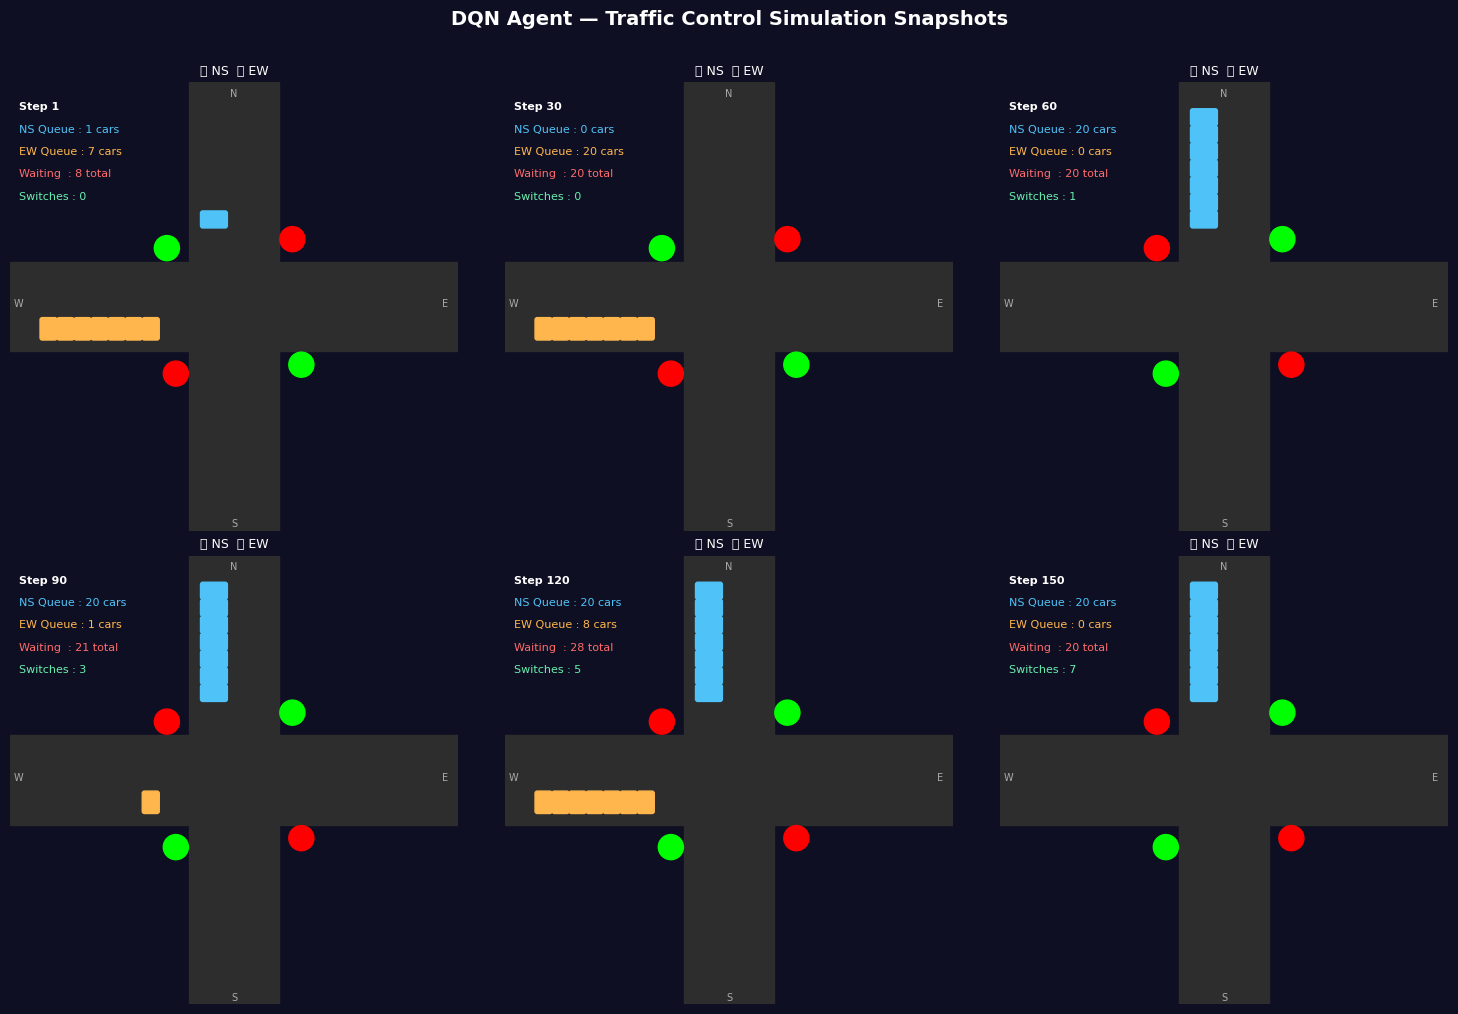


✅ Simulation Complete!
   Total Reward    : -4422
   Avg Waiting     : 22.11 cars/step
   Signal Switches : 9


In [ ]:
# ── CELL 12 (FIXED): Visual Simulation Snapshots ──

def run_snapshot_simulation(agent, n_snapshots=6):
    env = TrafficEnv()
    obs, _ = env.reset()
    total_reward = 0
    done = False

    snapshots = []
    step = 0

    while not done:
        action = agent.choose_action(obs)
        obs, reward, done, _, info = env.step(action)
        total_reward += reward
        step += 1
        # Capture snapshot every 30 steps
        if step % 30 == 0 or step == 1:
            snapshots.append({
                'step'      : step,
                'queue_NS'  : info['queue_NS'],
                'queue_EW'  : info['queue_EW'],
                'phase'     : int(obs[2]),
                'waiting'   : info['queue_NS'] + info['queue_EW'],
                'reward'    : total_reward,
                'switches'  : info['switches']
            })

    env.close()

    # ── Draw snapshots ──
    n = min(len(snapshots), n_snapshots)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.patch.set_facecolor('#0f0f23')
    fig.suptitle('DQN Agent — Traffic Control Simulation Snapshots',
                 color='white', fontsize=14, fontweight='bold', y=1.01)
    axes = axes.flatten()

    for i in range(n):
        s   = snapshots[i]
        ax  = axes[i]
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_facecolor('#1a1a2e')
        ax.set_aspect('equal')
        ax.axis('off')

        # Roads
        ax.add_patch(patches.Rectangle((0, 4), 10, 2, color='#2d2d2d'))
        ax.add_patch(patches.Rectangle((4, 0), 2, 10, color='#2d2d2d'))
        ax.add_patch(patches.Rectangle((4, 4), 2, 2,  color='#2d2d2d'))

        # Traffic lights
        ns_color = '#00ff00' if s['phase'] == 0 else '#ff0000'
        ew_color = '#ff0000' if s['phase'] == 0 else '#00ff00'
        ax.add_patch(patches.Circle((3.5, 6.3), 0.28, color=ns_color, zorder=5))
        ax.add_patch(patches.Circle((6.5, 3.7), 0.28, color=ns_color, zorder=5))
        ax.add_patch(patches.Circle((3.7, 3.5), 0.28, color=ew_color, zorder=5))
        ax.add_patch(patches.Circle((6.3, 6.5), 0.28, color=ew_color, zorder=5))

        # NS cars (blue)
        ns_cars = min(int(s['queue_NS']), 7)
        for j in range(ns_cars):
            y = 6.8 + j * 0.38
            if y < 9.5:
                ax.add_patch(patches.FancyBboxPatch(
                    (4.3, y), 0.5, 0.28,
                    boxstyle="round,pad=0.05",
                    color='#4fc3f7', zorder=4))

        # EW cars (orange)
        ew_cars = min(int(s['queue_EW']), 7)
        for j in range(ew_cars):
            x = 3.0 - j * 0.38
            if x > 0.5:
                ax.add_patch(patches.FancyBboxPatch(
                    (x, 4.3), 0.28, 0.4,
                    boxstyle="round,pad=0.05",
                    color='#ffb74d', zorder=4))

        # Direction labels
        ax.text(5,   9.7, 'N', ha='center', color='white', fontsize=7, alpha=0.6)
        ax.text(5,   0.1, 'S', ha='center', color='white', fontsize=7, alpha=0.6)
        ax.text(0.2, 5,   'W', ha='center', color='white', fontsize=7, alpha=0.6)
        ax.text(9.7, 5,   'E', ha='center', color='white', fontsize=7, alpha=0.6)

        # Phase text
        phase_txt = '🟢 NS  🔴 EW' if s['phase'] == 0 else '🔴 NS  🟢 EW'

        # Info
        ax.text(0.2, 9.4, f"Step {s['step']}",          color='white',   fontsize=8, fontweight='bold')
        ax.text(0.2, 8.9, f"NS Queue : {int(s['queue_NS'])} cars", color='#4fc3f7', fontsize=8)
        ax.text(0.2, 8.4, f"EW Queue : {int(s['queue_EW'])} cars", color='#ffb74d', fontsize=8)
        ax.text(0.2, 7.9, f"Waiting  : {int(s['waiting'])} total", color='#ff6b6b', fontsize=8)
        ax.text(0.2, 7.4, f"Switches : {s['switches']}",           color='#69f0ae', fontsize=8)
        ax.set_title(phase_txt, color='white', fontsize=9, pad=6)

    # Hide unused axes
    for i in range(n, 6):
        axes[i].axis('off')
        axes[i].set_facecolor('#0f0f23')

    plt.tight_layout()
    plt.savefig('simulation_snapshots.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f23')
    plt.show()

    print(f"\n✅ Simulation Complete!")
    print(f"   Total Reward    : {total_reward:.0f}")
    print(f"   Avg Waiting     : {info['avg_waiting']:.2f} cars/step")
    print(f"   Signal Switches : {info['switches']}")


print("🚦 Running DQN Visual Simulation...")
run_snapshot_simulation(dqn_agent, n_snapshots=6)

✅ Simulation Output:


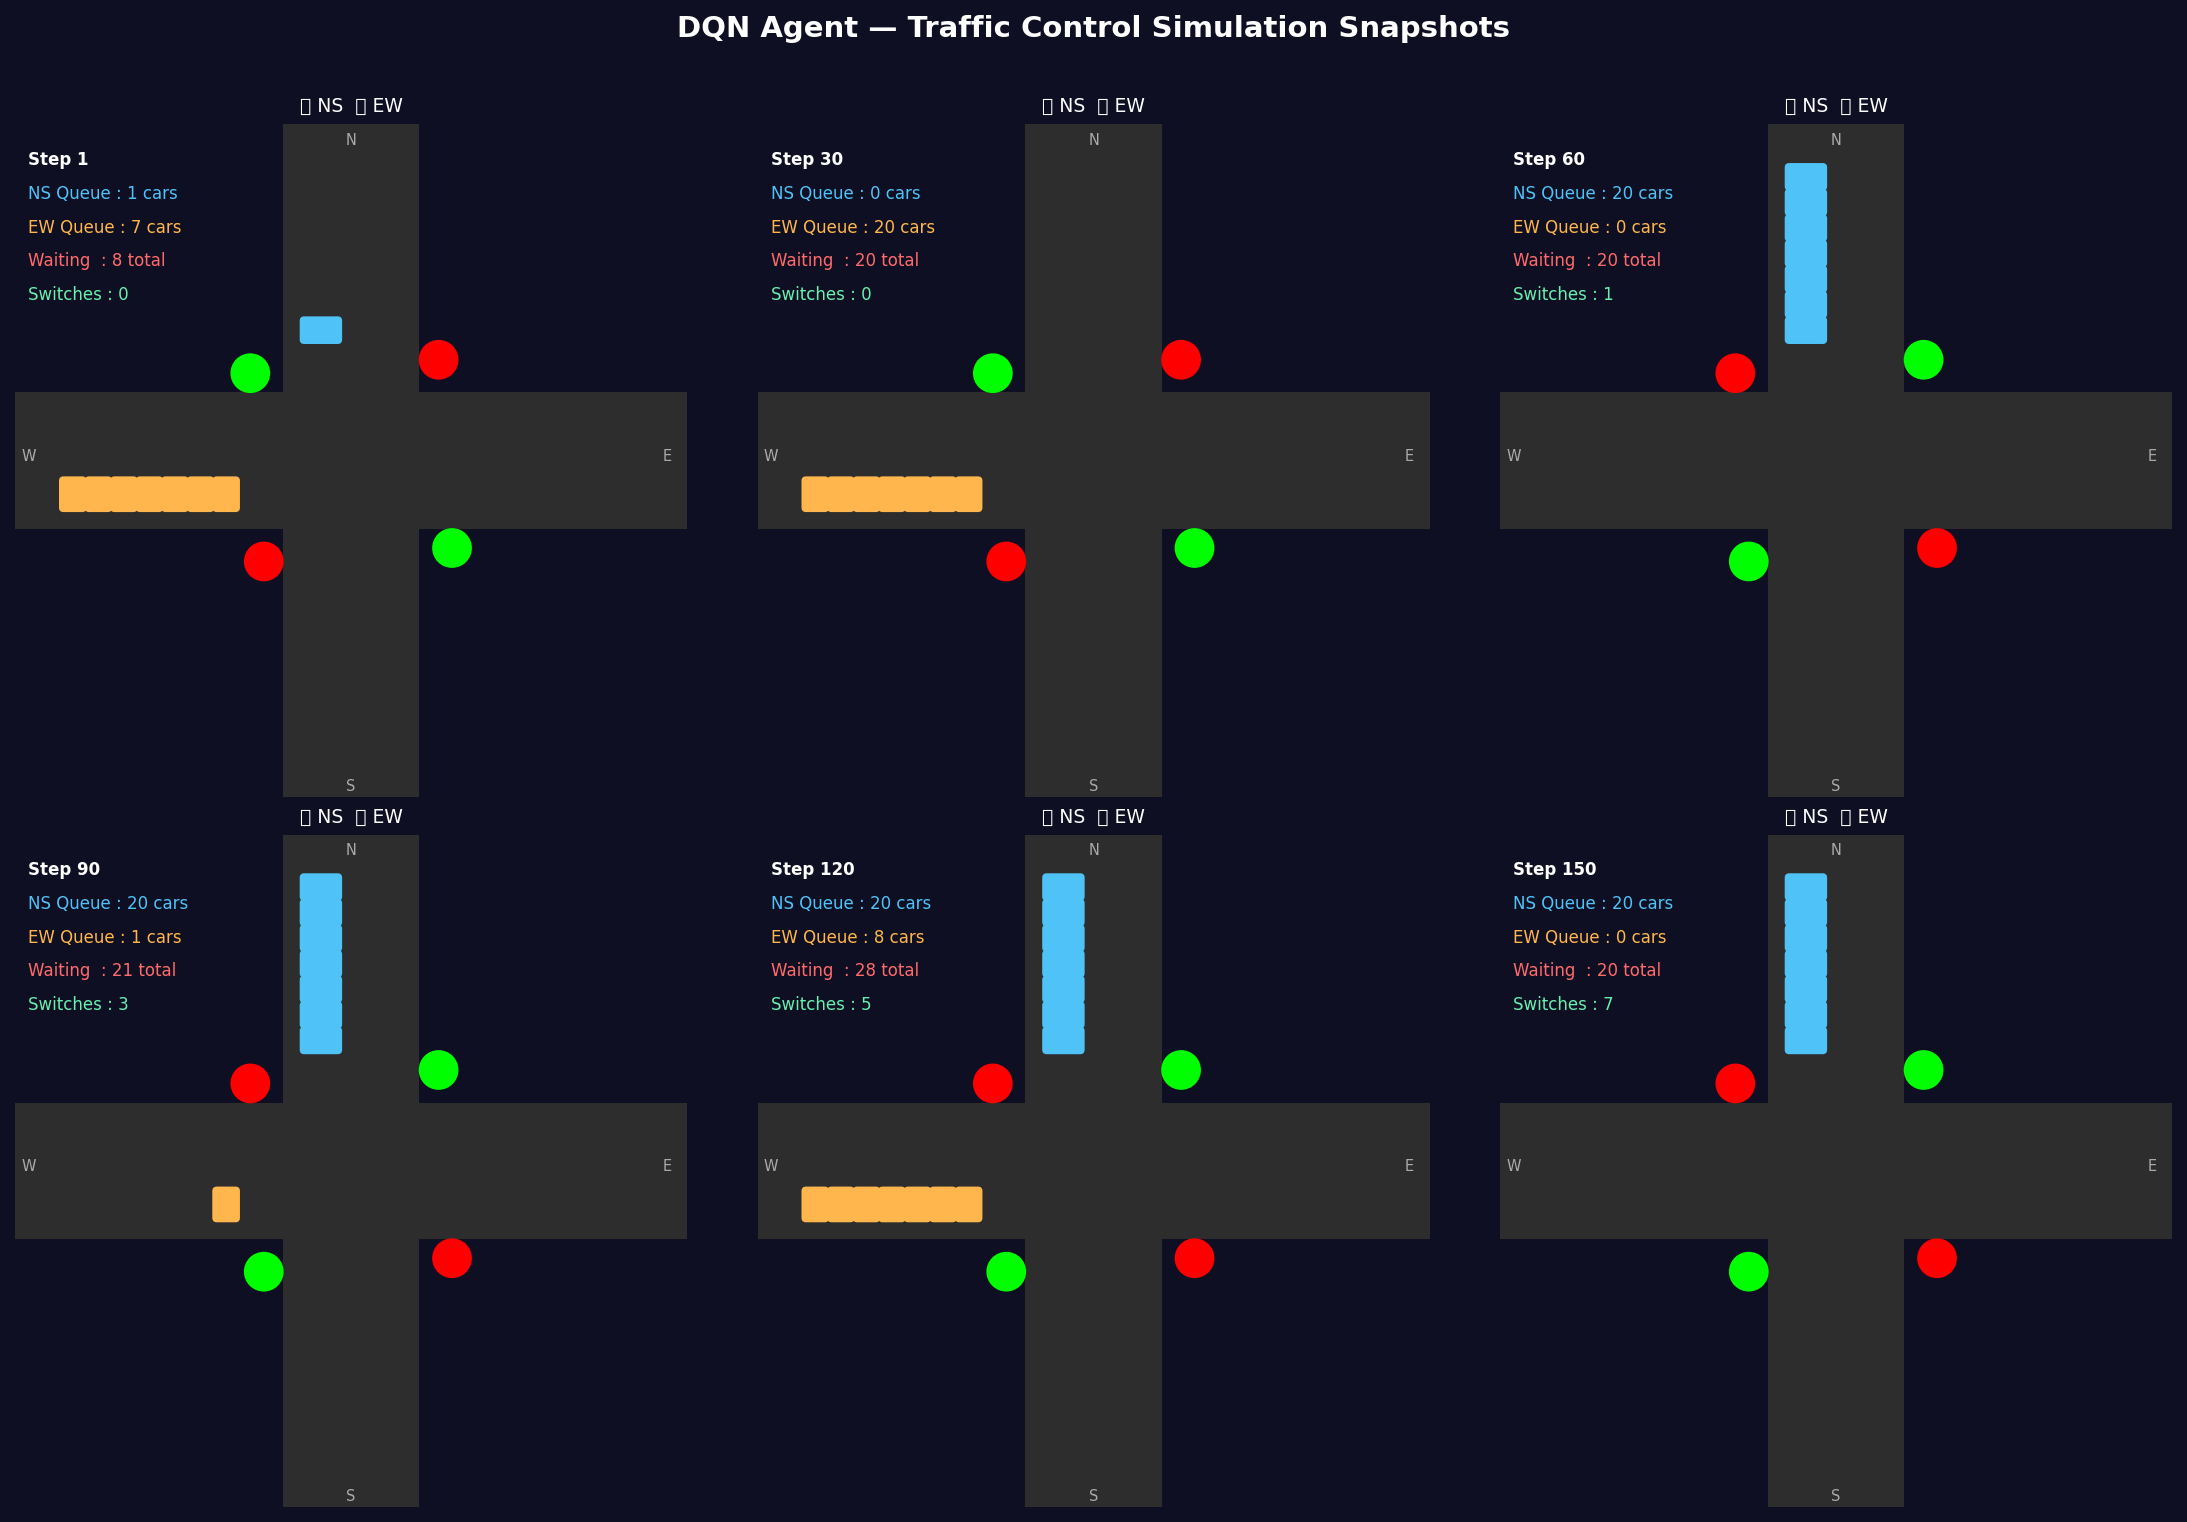


✅ Training Results:


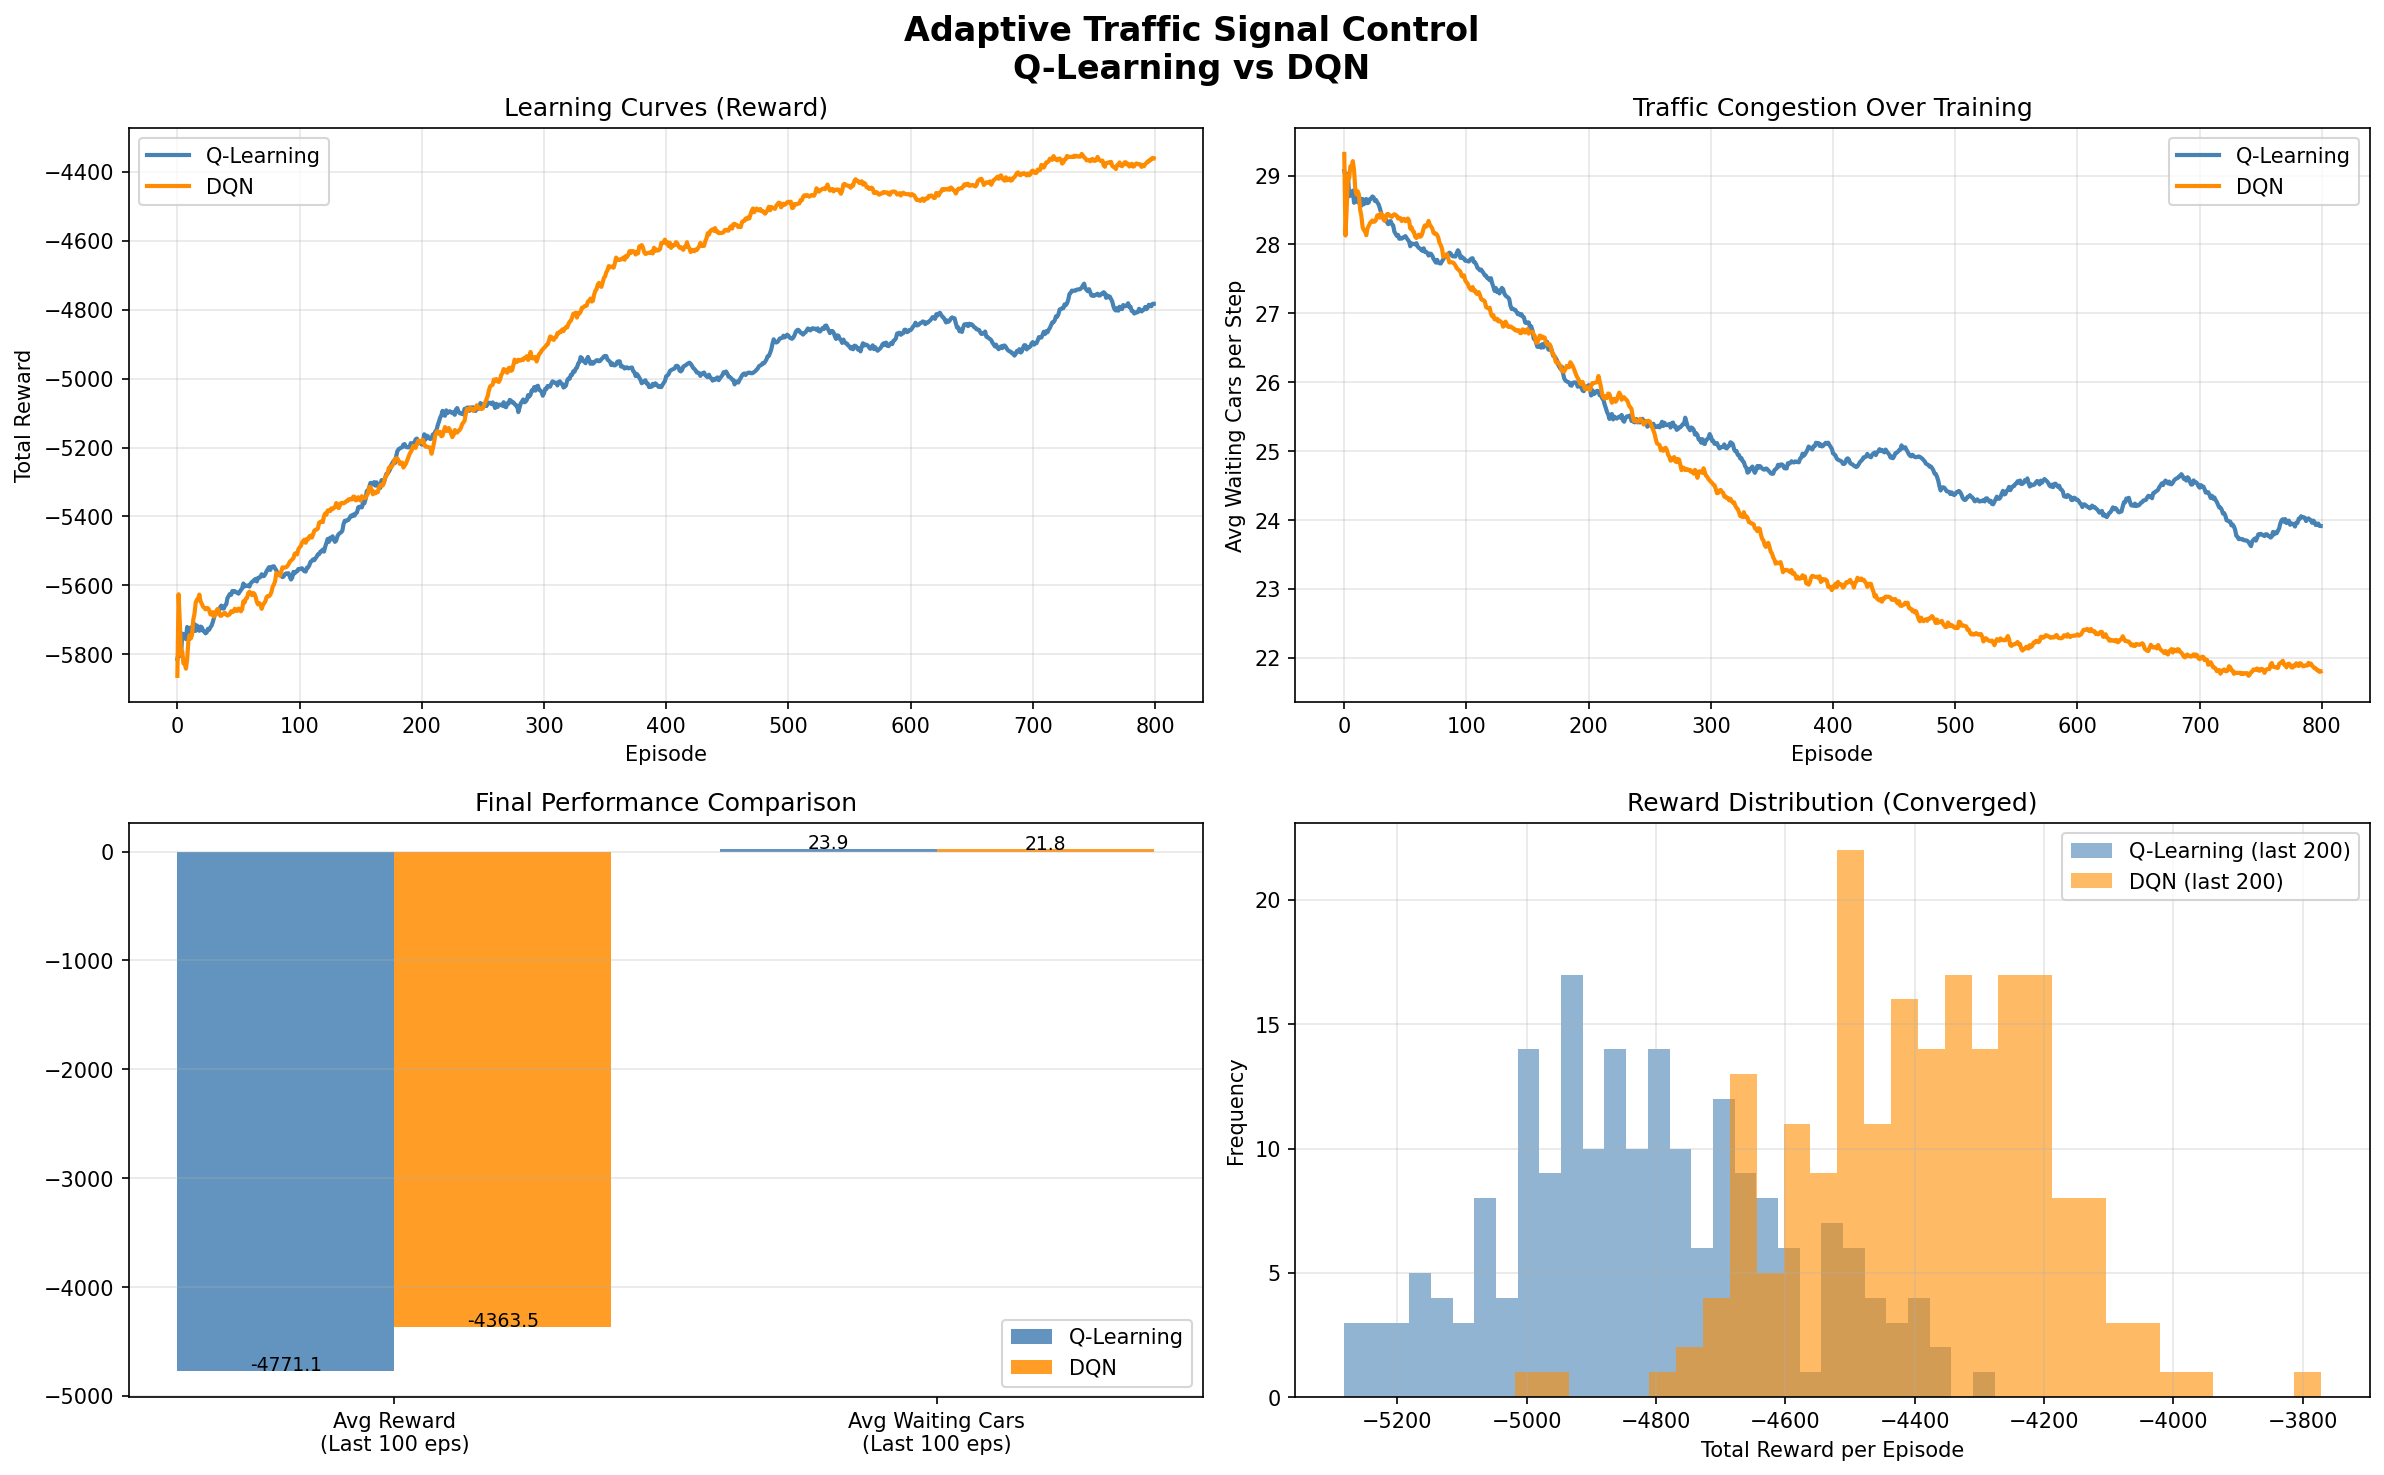

In [ ]:
# ── CELL 15 (FINAL - NO ANIMATION) ──
from IPython.display import Image, display

# Just show the snapshot simulation we already made
print("✅ Simulation Output:")
display(Image('simulation_snapshots.png'))

print("\n✅ Training Results:")
display(Image('traffic_rl_results.png'))